# Import Libraries

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.0.2


# Set Dataset Path

In [2]:
DATA_DIR = Path(
    "/kaggle/input/datasets/mostafaabla/garbage-classification/garbage_classification"
)

print("Dataset exists:", DATA_DIR.exists())
print("Dataset path:", DATA_DIR)

Dataset exists: True
Dataset path: /kaggle/input/datasets/mostafaabla/garbage-classification/garbage_classification


# Explore Dataset Contents

In [3]:
print("Contents of dataset:\n")

for item in DATA_DIR.iterdir():
    print(item.name)

Contents of dataset:

metal
white-glass
biological
paper
brown-glass
battery
trash
cardboard
shoes
clothes
plastic
green-glass


# Get Class Names

In [4]:
classes = sorted([
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
])

print("Number of classes:", len(classes))
print("\nClasses:")

for i, class_name in enumerate(classes):
    print(f"{i}: {class_name}")

Number of classes: 12

Classes:
0: battery
1: biological
2: brown-glass
3: cardboard
4: clothes
5: green-glass
6: metal
7: paper
8: plastic
9: shoes
10: trash
11: white-glass


# Count Images per Class

In [5]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

class_counts = {}

for class_name in classes:
    class_path = DATA_DIR / class_name
    
    count = sum(
        1
        for file in class_path.iterdir()
        if file.suffix.lower() in image_extensions
    )
    
    class_counts[class_name] = count

class_counts

{'battery': 945,
 'biological': 985,
 'brown-glass': 607,
 'cardboard': 891,
 'clothes': 5325,
 'green-glass': 629,
 'metal': 769,
 'paper': 1050,
 'plastic': 865,
 'shoes': 1977,
 'trash': 697,
 'white-glass': 775}

#  Class Distribution

In [6]:
class_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

class_df

,Class,Number of Images
0,battery,945
1,biological,985
2,brown-glass,607
3,cardboard,891
4,clothes,5325
5,green-glass,629
6,metal,769
7,paper,1050
8,plastic,865
9,shoes,1977


# Tot Number of Images

In [7]:
total_images = class_df["Number of Images"].sum()

print("Total number of images:", total_images)

Total number of images: 15515


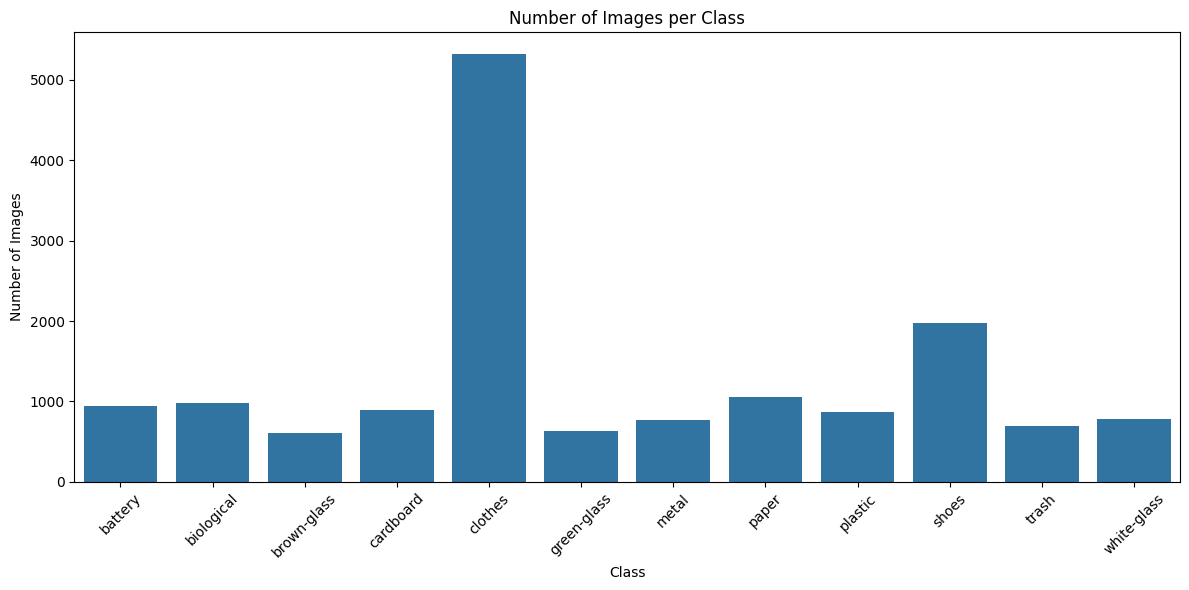

In [8]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=class_df,
    x="Class",
    y="Number of Images"
)

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#  Display Sample Images

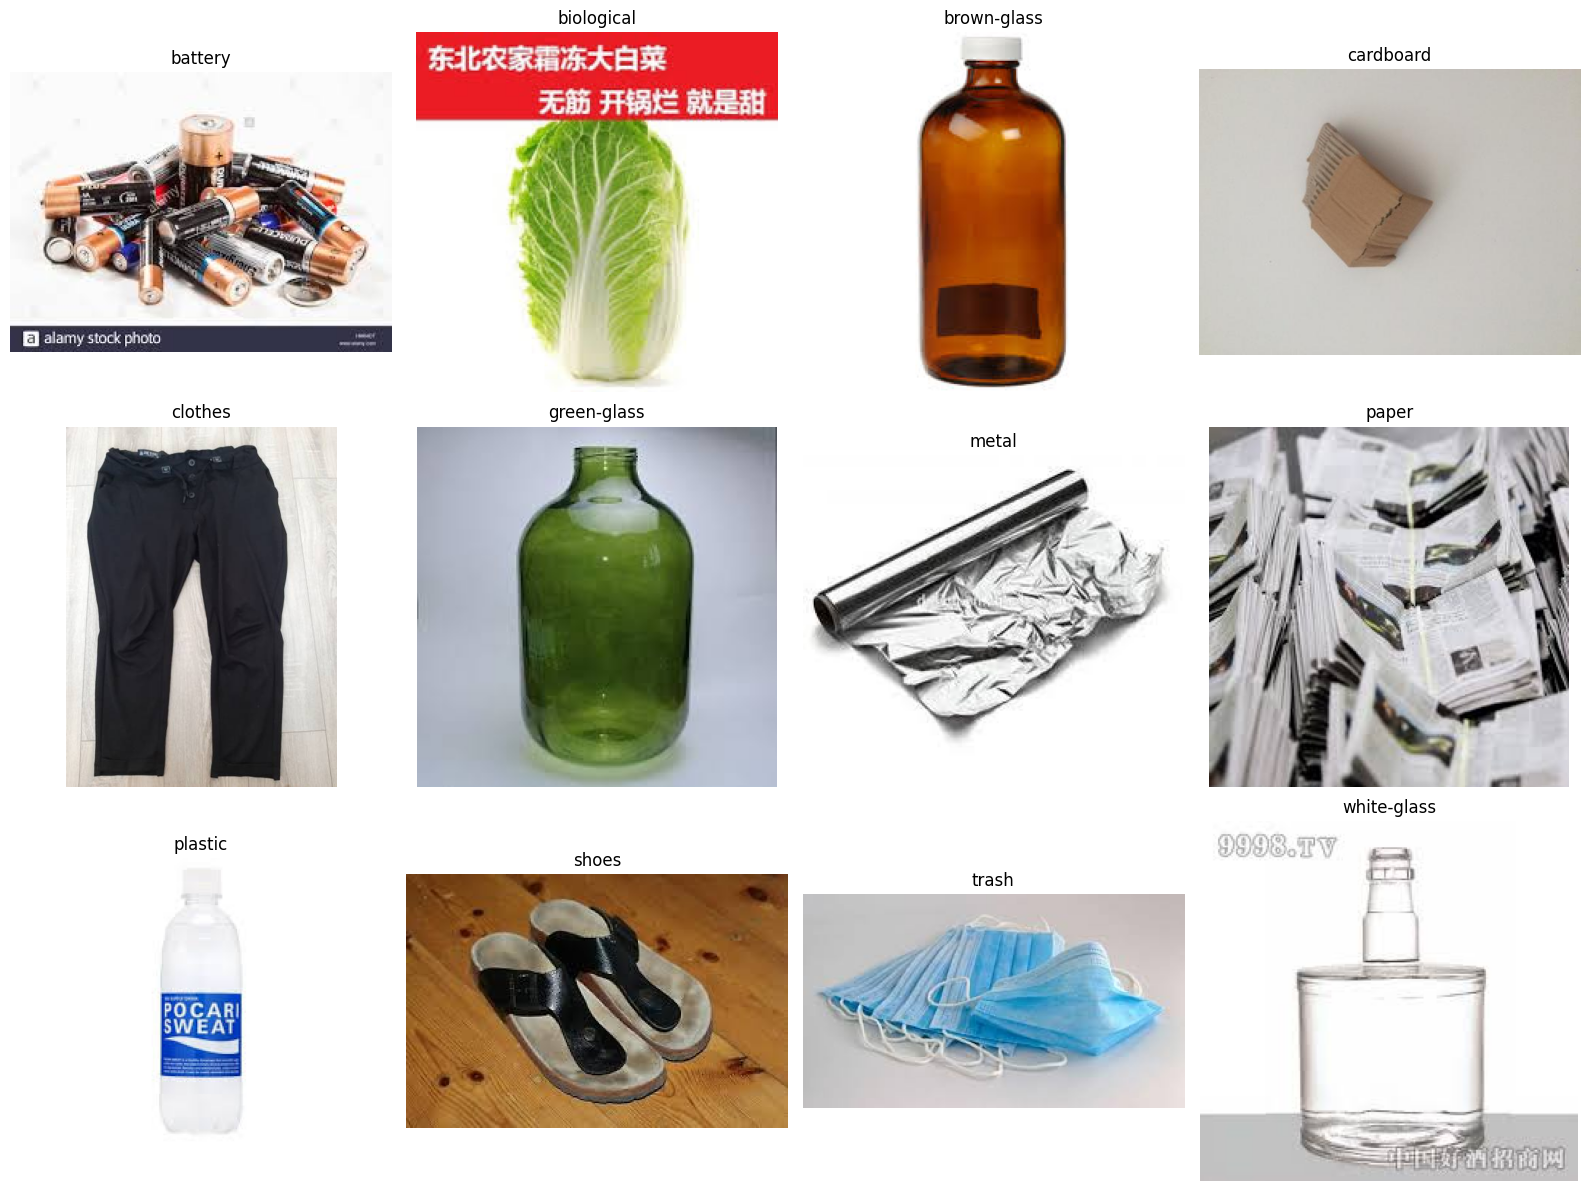

In [9]:
plt.figure(figsize=(16, 12))

for i, class_name in enumerate(classes):
    
    class_path = DATA_DIR / class_name
    
    image_files = [
        file for file in class_path.iterdir()
        if file.suffix.lower() in image_extensions
    ]
    
    image_path = random.choice(image_files)
    
    image = Image.open(image_path)
    
    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Image Dimensions

In [10]:
sample_sizes = []

for class_name in classes:
    
    class_path = DATA_DIR / class_name
    
    image_files = [
        file for file in class_path.iterdir()
        if file.suffix.lower() in image_extensions
    ]
    
    for image_path in random.sample(
        image_files,
        min(10, len(image_files))
    ):
        try:
            with Image.open(image_path) as img:
                sample_sizes.append(img.size)
        except:
            pass

size_df = pd.DataFrame(
    sample_sizes,
    columns=["Width", "Height"]
)

size_df.describe()

,Width,Height
count,120.000000,120.000000
mean,337.708333,290.258333
std,121.638422,126.180243
min,138.000000,112.000000
25%,225.000000,193.750000
50%,275.000000,225.000000
75%,512.000000,384.000000
max,534.000000,867.000000


# Dataset DataFrame

In [11]:
data = []

class_to_index = {
    class_name: index
    for index, class_name in enumerate(classes)
}

for class_name in classes:
    
    class_path = DATA_DIR / class_name
    
    image_files = [
        file for file in class_path.iterdir()
        if file.suffix.lower() in image_extensions
    ]
    
    for image_path in image_files:
        data.append({
            "image_path": str(image_path),
            "class": class_name,
            "label": class_to_index[class_name]
        })

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (15515, 3)


,image_path,class,label
0,/kaggle/input/datasets/mostafaabla/garbage-cla...,battery,0
1,/kaggle/input/datasets/mostafaabla/garbage-cla...,battery,0
2,/kaggle/input/datasets/mostafaabla/garbage-cla...,battery,0
3,/kaggle/input/datasets/mostafaabla/garbage-cla...,battery,0
4,/kaggle/input/datasets/mostafaabla/garbage-cla...,battery,0


# Data Cleaning

In [12]:
# Check for corrupted or unreadable images

valid_images = []
corrupted_images = []

for image_path in df["image_path"]:
    try:
        with Image.open(image_path) as img:
            img.verify()
        valid_images.append(image_path)
        
    except Exception:
        corrupted_images.append(image_path)

print("Total images:", len(df))
print("Valid images:", len(valid_images))
print("Corrupted images:", len(corrupted_images))

Total images: 15515
Valid images: 15515
Corrupted images: 0


# Train / Validation / Test Split

In [13]:
# First split: 80% Train, 20% Temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

# Second split: 10% Validation, 10% Test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 12412
Validation size: 1551
Test size: 1552


#  Check Split Distribution

In [14]:
# Count images per class in each split

split_distribution = pd.DataFrame({
    "Train": train_df["class"].value_counts(),
    "Validation": val_df["class"].value_counts(),
    "Test": test_df["class"].value_counts()
})

split_distribution = split_distribution.sort_index()

split_distribution

,Train,Validation,Test
class,,,
battery,756,94,95
biological,788,98,99
brown-glass,485,61,61
cardboard,713,89,89
clothes,4260,532,533
green-glass,503,63,63
metal,615,77,77
paper,840,105,105
plastic,692,87,86


In [15]:
split_percentages = split_distribution.div(
    split_distribution.sum(axis=0),
    axis=1
) * 100

split_percentages.round(2)

,Train,Validation,Test
class,,,
battery,6.09,6.06,6.12
biological,6.35,6.32,6.38
brown-glass,3.91,3.93,3.93
cardboard,5.74,5.74,5.73
clothes,34.32,34.30,34.34
green-glass,4.05,4.06,4.06
metal,4.95,4.96,4.96
paper,6.77,6.77,6.77
plastic,5.58,5.61,5.54


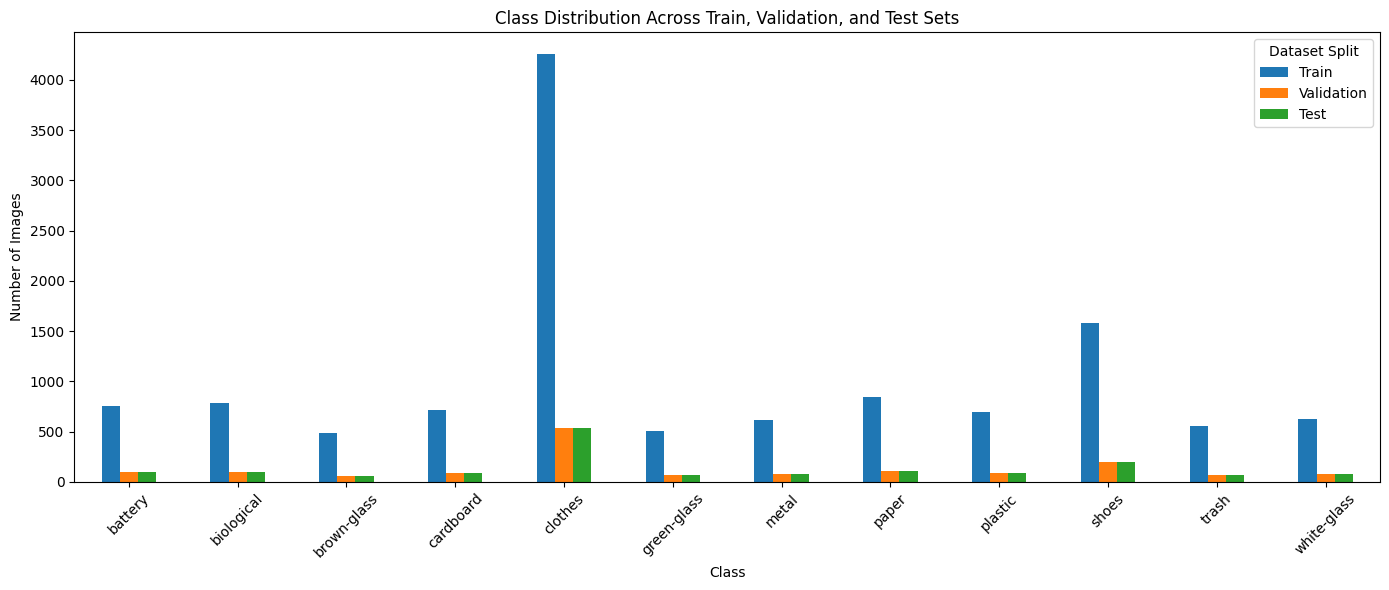

In [16]:
split_distribution.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.legend(title="Dataset Split")

plt.tight_layout()
plt.show()

# Data Augmentation

In [17]:
# Image settings

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(classes)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

Image size: (224, 224)
Batch size: 32
Number of classes: 12


# Define Data Augmentation

In [18]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

I0000 00:00:1786322877.202183      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786322877.205163      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [19]:
print("TensorFlow version:", tf.__version__)

print("\nGPU devices:")
print(tf.config.list_physical_devices("GPU"))

print("\nCPU devices:")
print(tf.config.list_physical_devices("CPU"))

TensorFlow version: 2.20.0

GPU devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

CPU devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


# Create Image Loading Function

In [20]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label

#  Create TensorFlow Datasets

In [21]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label"].values
    )
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["label"].values
    )
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values,
        test_df["label"].values
    )
)

print("Datasets created successfully.")

Datasets created successfully.


# Apply Image Preprocessing

In [22]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .shuffle(len(train_df), seed=42)
    .map(load_image, num_parallel_calls=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
)

print("Preprocessing completed.")

Preprocessing completed.


# Create Batches

In [23]:
train_ds = (
    train_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Batching completed.")

Batching completed.


# test the data pipline

In [24]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
Label data type: <dtype: 'int64'>


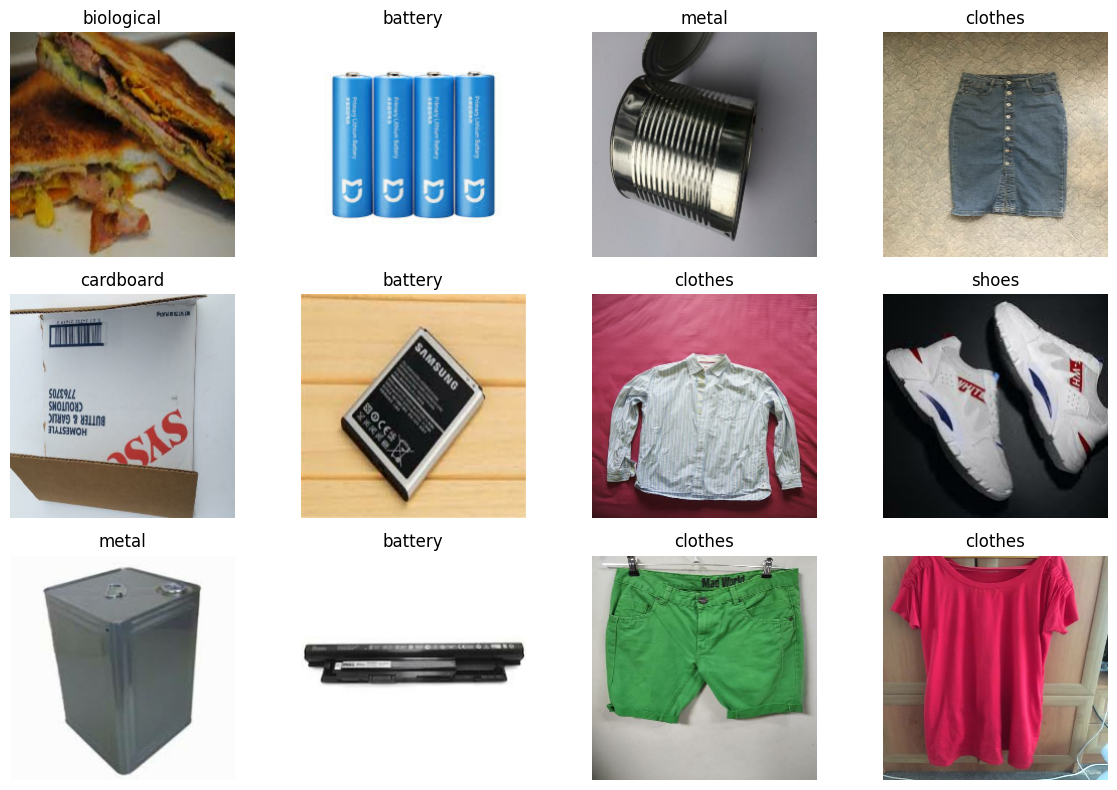

In [25]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(
        tf.cast(images[i], tf.uint8)
    )

    plt.title(classes[labels[i].numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Prepare MobileNetV2

In [26]:
# Load MobileNetV2 pretrained on ImageNet

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the pretrained layers
base_model.trainable = False

print("MobileNetV2 loaded successfully.")
print("Number of layers:", len(base_model.layers))
print("Trainable:", base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully.
Number of layers: 154
Trainable: False


In [27]:
# Build MobileNetV2 classification model

inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

# MobileNetV2 preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

mobilenet_model = keras.Model(
    inputs,
    outputs,
    name="MobileNetV2_Garbage_Classifier"
)

mobilenet_model.summary()

Model: "MobileNetV2_Garbage_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │        15,372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,273,356 (8.67 MB)

 Trainable params: 15,372 (60.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Compile MobileNetV2 - Stage 1

In [28]:
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 compiled successfully.")

MobileNetV2 compiled successfully.


#  Define Training Callbacks

In [29]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        "mobilenetv2_best_stage1.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks created successfully.")

Callbacks created successfully.


# Train MobileNetV2 - Stage 1

In [30]:
history_mobilenet_stage1 = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7036 - loss: 0.9853
Epoch 1: val_loss improved from None to 0.29019, saving model to mobilenetv2_best_stage1.keras

Epoch 1: finished saving model to mobilenetv2_best_stage1.keras
388/388 ━━━━━━━━━━━━━━━━━━━━ 33s 62ms/step - accuracy: 0.8198 - loss: 0.5929 - val_accuracy: 0.9104 - val_loss: 0.2902 - learning_rate: 0.0010
Epoch 2/15
387/388 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8999 - loss: 0.3124
Epoch 2: val_loss improved from 0.29019 to 0.24498, saving model to mobilenetv2_best_stage1.keras

Epoch 2: finished saving model to mobilenetv2_best_stage1.keras
388/388 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.9071 - loss: 0.2936 - val_accuracy: 0.9271 - val_loss: 0.2450 - learning_rate: 0.0010
Epoch 3/15
387/388 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9198 - loss: 0.2480
Epoch 3: val_loss improved from 0.24498 to 0.21454, saving model to mobilenetv2_best_stage1.keras

Epoch 3: finished saving model 

# Plot MobileNetV2 Stage 1 History

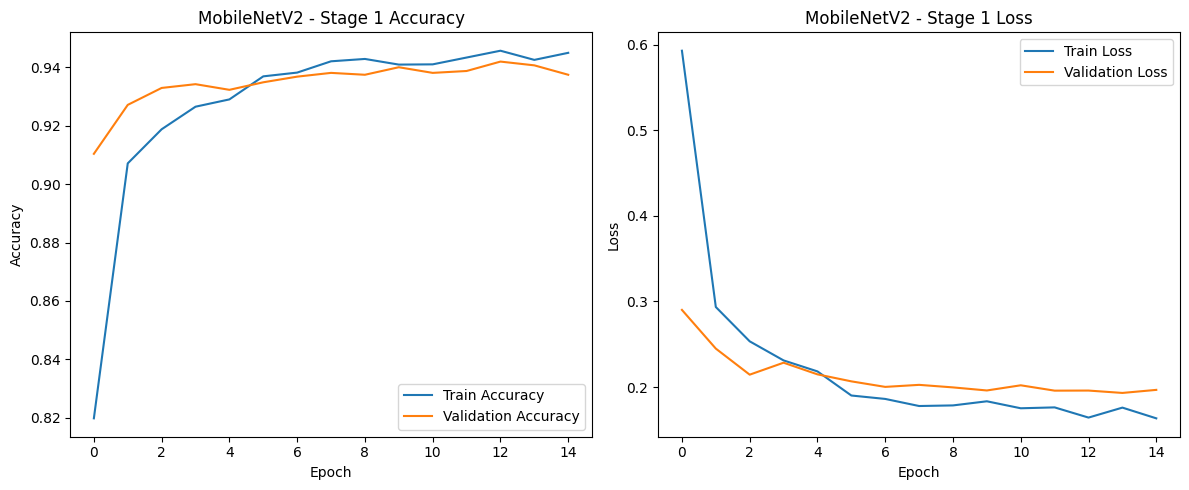

In [31]:
history = history_mobilenet_stage1.history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(history["accuracy"], label="Train Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")

plt.title("MobileNetV2 - Stage 1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(history["loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.title("MobileNetV2 - Stage 1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate MobileNetV2 Stage 1

In [32]:
stage1_test_loss, stage1_test_accuracy = mobilenet_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss: {stage1_test_loss:.4f}")
print(f"Test Accuracy: {stage1_test_accuracy:.4f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9491 - loss: 0.1704
Test Loss: 0.1704
Test Accuracy: 0.9491


#  Generate MobileNetV2 Stage 1 Predictions

In [33]:
y_true = []
y_pred = []

for images_batch, labels_batch in test_ds:
    predictions = mobilenet_model.predict(
        images_batch,
        verbose=0
    )
    
    y_true.extend(labels_batch.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of test samples:", len(y_true))

Number of test samples: 1552


# MobileNetV2 Stage 1 Classification Report

In [34]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes,
        digits=4
    )
)

              precision    recall  f1-score   support

     battery     0.9767    0.8842    0.9282        95
  biological     0.9703    0.9899    0.9800        99
 brown-glass     0.9500    0.9344    0.9421        61
   cardboard     0.9362    0.9888    0.9617        89
     clothes     0.9887    0.9887    0.9887       533
 green-glass     0.9355    0.9206    0.9280        63
       metal     0.8537    0.9091    0.8805        77
       paper     0.9000    0.9429    0.9209       105
     plastic     0.8780    0.8372    0.8571        86
       shoes     0.9552    0.9697    0.9624       198
       trash     1.0000    0.9275    0.9624        69
 white-glass     0.8312    0.8312    0.8312        77

    accuracy                         0.9491      1552
   macro avg     0.9313    0.9270    0.9286      1552
weighted avg     0.9497    0.9491    0.9490      1552



# MobileNetV2 Fine-Tuning

In [35]:
# Unfreeze the top layers of MobileNetV2
base_model.trainable = True

# Freeze all layers except the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total layers: 154
Trainable layers: 30


# Compile MobileNetV2 - Fine-Tuning

In [36]:
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 fine-tuning model compiled successfully.")

MobileNetV2 fine-tuning model compiled successfully.


In [37]:
fine_tune_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        "mobilenetv2_best_finetuned.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Fine-tuning callbacks created successfully.")

Fine-tuning callbacks created successfully.


# Train MobileNetV2 - Fine-Tuning

In [38]:
history_mobilenet_finetune = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=fine_tune_callbacks
)

Epoch 1/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8836 - loss: 0.3689
Epoch 1: val_loss improved from None to 0.20245, saving model to mobilenetv2_best_finetuned.keras

Epoch 1: finished saving model to mobilenetv2_best_finetuned.keras
388/388 ━━━━━━━━━━━━━━━━━━━━ 44s 89ms/step - accuracy: 0.8953 - loss: 0.3228 - val_accuracy: 0.9407 - val_loss: 0.2024 - learning_rate: 1.0000e-05
Epoch 2/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9164 - loss: 0.2596
Epoch 2: val_loss improved from 0.20245 to 0.20203, saving model to mobilenetv2_best_finetuned.keras

Epoch 2: finished saving model to mobilenetv2_best_finetuned.keras
388/388 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.9165 - loss: 0.2550 - val_accuracy: 0.9458 - val_loss: 0.2020 - learning_rate: 1.0000e-05
Epoch 3/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9310 - loss: 0.2188
Epoch 3: val_loss improved from 0.20203 to 0.19442, saving model to mobilenetv2_best_finetuned.keras

Epoch 3:

# Evaluate Fine-Tuned MobileNetV2

In [39]:
finetune_test_loss, finetune_test_accuracy = mobilenet_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Fine-Tuned Test Loss: {finetune_test_loss:.4f}")
print(f"Fine-Tuned Test Accuracy: {finetune_test_accuracy:.4f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9601 - loss: 0.1332
Fine-Tuned Test Loss: 0.1332
Fine-Tuned Test Accuracy: 0.9601


#  Fine-Tuned MobileNetV2 Classification Report

In [40]:
y_true_ft = []
y_pred_ft = []

for images_batch, labels_batch in test_ds:
    predictions = mobilenet_model.predict(
        images_batch,
        verbose=0
    )

    y_true_ft.extend(labels_batch.numpy())
    y_pred_ft.extend(np.argmax(predictions, axis=1))

y_true_ft = np.array(y_true_ft)
y_pred_ft = np.array(y_pred_ft)

print(
    classification_report(
        y_true_ft,
        y_pred_ft,
        target_names=classes,
        digits=4
    )
)

              precision    recall  f1-score   support

     battery     0.9778    0.9263    0.9514        95
  biological     1.0000    0.9798    0.9898        99
 brown-glass     0.9516    0.9672    0.9593        61
   cardboard     0.9775    0.9775    0.9775        89
     clothes     0.9906    0.9906    0.9906       533
 green-glass     0.9524    0.9524    0.9524        63
       metal     0.8765    0.9221    0.8987        77
       paper     0.9196    0.9810    0.9493       105
     plastic     0.8621    0.8721    0.8671        86
       shoes     0.9646    0.9646    0.9646       198
       trash     1.0000    0.9565    0.9778        69
 white-glass     0.8784    0.8442    0.8609        77

    accuracy                         0.9601      1552
   macro avg     0.9459    0.9445    0.9450      1552
weighted avg     0.9605    0.9601    0.9601      1552



# MobileNetV2 Performance Comparison

In [41]:
mobilenet_results = pd.DataFrame({
    "Stage": [
        "Feature Extraction",
        "Fine-Tuning"
    ],
    "Test Accuracy": [
        stage1_test_accuracy,
        finetune_test_accuracy
    ],
    "Test Loss": [
        stage1_test_loss,
        finetune_test_loss
    ]
})

mobilenet_results

,Stage,Test Accuracy,Test Loss
0,Feature Extraction,0.949098,0.170440
1,Fine-Tuning,0.960052,0.133203


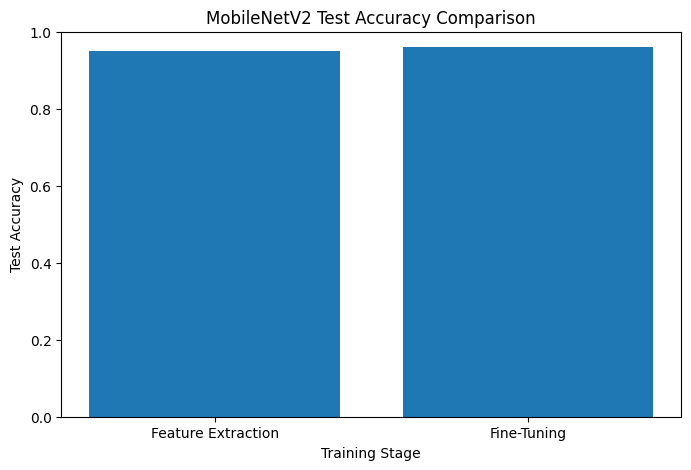

In [42]:
plt.figure(figsize=(8, 5))

plt.bar(
    mobilenet_results["Stage"],
    mobilenet_results["Test Accuracy"]
)

plt.title("MobileNetV2 Test Accuracy Comparison")
plt.xlabel("Training Stage")
plt.ylabel("Test Accuracy")

plt.ylim(0, 1)

plt.show()

#-----------------------------------------------------------------
# Prepare Xception
#-----------------------------------------------------------------

In [43]:
# Load Xception pretrained on ImageNet

xception_base = tf.keras.applications.Xception(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the pretrained layers
xception_base.trainable = False

print("Xception loaded successfully.")
print("Number of layers:", len(xception_base.layers))
print("Trainable:", xception_base.trainable)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Xception loaded successfully.
Number of layers: 132
Trainable: False


# Build Xception Model

In [44]:
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

# Xception preprocessing
x = tf.keras.applications.xception.preprocess_input(x)

x = xception_base(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

xception_model = keras.Model(
    inputs,
    outputs,
    name="Xception_Garbage_Classifier"
)

xception_model.summary()

Model: "Xception_Garbage_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │        24,588 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,886,068 (79.67 MB)

 Trainable params: 24,588 (96.05 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

#  Compile Xception - Stage 1

In [45]:
xception_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Xception compiled successfully.")

Xception compiled successfully.


# Xception Training Callbacks

In [46]:
xception_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        "xception_best_stage1.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Xception callbacks created successfully.")

Xception callbacks created successfully.


# Train Xception - Stage 1

In [47]:
history_xception_stage1 = xception_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=xception_callbacks
)

Epoch 1/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.7402 - loss: 0.8814
Epoch 1: val_loss improved from None to 0.29206, saving model to xception_best_stage1.keras

Epoch 1: finished saving model to xception_best_stage1.keras
388/388 ━━━━━━━━━━━━━━━━━━━━ 103s 249ms/step - accuracy: 0.8398 - loss: 0.5494 - val_accuracy: 0.9168 - val_loss: 0.2921 - learning_rate: 0.0010
Epoch 2/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9071 - loss: 0.3105
Epoch 2: val_loss improved from 0.29206 to 0.25139, saving model to xception_best_stage1.keras

Epoch 2: finished saving model to xception_best_stage1.keras
388/388 ━━━━━━━━━━━━━━━━━━━━ 92s 236ms/step - accuracy: 0.9078 - loss: 0.2958 - val_accuracy: 0.9329 - val_loss: 0.2514 - learning_rate: 0.0010
Epoch 3/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9186 - loss: 0.2588
Epoch 3: val_loss improved from 0.25139 to 0.23060, saving model to xception_best_stage1.keras

Epoch 3: finished saving model to xcepti

#  Evaluate Xception - Stage 1

In [48]:
xception_stage1_test_loss, xception_stage1_test_accuracy = xception_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Xception Stage 1 Test Loss: {xception_stage1_test_loss:.4f}")
print(f"Xception Stage 1 Test Accuracy: {xception_stage1_test_accuracy:.4f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step - accuracy: 0.9369 - loss: 0.1886
Xception Stage 1 Test Loss: 0.1886
Xception Stage 1 Test Accuracy: 0.9369


# Xception Stage 1 Classification Report

In [49]:
y_true_xc = []
y_pred_xc = []

for images_batch, labels_batch in test_ds:
    predictions = xception_model.predict(
        images_batch,
        verbose=0
    )

    y_true_xc.extend(labels_batch.numpy())
    y_pred_xc.extend(np.argmax(predictions, axis=1))

y_true_xc = np.array(y_true_xc)
y_pred_xc = np.array(y_pred_xc)

print(
    classification_report(
        y_true_xc,
        y_pred_xc,
        target_names=classes,
        digits=4
    )
)

              precision    recall  f1-score   support

     battery     0.9158    0.9158    0.9158        95
  biological     0.9794    0.9596    0.9694        99
 brown-glass     0.8621    0.8197    0.8403        61
   cardboard     0.9333    0.9438    0.9385        89
     clothes     0.9887    0.9887    0.9887       533
 green-glass     0.8261    0.9048    0.8636        63
       metal     0.8947    0.8831    0.8889        77
       paper     0.8942    0.8857    0.8900       105
     plastic     0.8000    0.8372    0.8182        86
       shoes     0.9652    0.9798    0.9724       198
       trash     0.9545    0.9130    0.9333        69
 white-glass     0.8767    0.8312    0.8533        77

    accuracy                         0.9369      1552
   macro avg     0.9076    0.9052    0.9060      1552
weighted avg     0.9373    0.9369    0.9369      1552



# Xception Fine-Tuning

In [50]:
# Unfreeze the Xception backbone

xception_base.trainable = True

# Freeze all layers except the last 30 layers
for layer in xception_base.layers[:-30]:
    layer.trainable = False

print("Total layers:", len(xception_base.layers))
print(
    "Trainable layers:",
    sum(layer.trainable for layer in xception_base.layers)
)

Total layers: 132
Trainable layers: 30


#  Compile Xception - Fine-Tuning

In [51]:
xception_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Xception fine-tuning model compiled successfully.")

Xception fine-tuning model compiled successfully.


#. Xception Fine-Tuning Callbacks

In [52]:
xception_fine_tune_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        "xception_best_finetuned.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Xception fine-tuning callbacks created successfully.")

Xception fine-tuning callbacks created successfully.


# Train Xception - Fine-Tuning

In [53]:
history_xception_finetune = xception_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=xception_fine_tune_callbacks
)

Epoch 1/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.8860 - loss: 0.4471
Epoch 1: val_loss improved from None to 0.20288, saving model to xception_best_finetuned.keras

Epoch 1: finished saving model to xception_best_finetuned.keras
388/388 ━━━━━━━━━━━━━━━━━━━━ 140s 338ms/step - accuracy: 0.9083 - loss: 0.3454 - val_accuracy: 0.9400 - val_loss: 0.2029 - learning_rate: 1.0000e-05
Epoch 2/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.9362 - loss: 0.2221
Epoch 2: val_loss improved from 0.20288 to 0.17395, saving model to xception_best_finetuned.keras

Epoch 2: finished saving model to xception_best_finetuned.keras
388/388 ━━━━━━━━━━━━━━━━━━━━ 127s 326ms/step - accuracy: 0.9375 - loss: 0.2125 - val_accuracy: 0.9491 - val_loss: 0.1739 - learning_rate: 1.0000e-05
Epoch 3/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.9416 - loss: 0.1832
Epoch 3: val_loss improved from 0.17395 to 0.16041, saving model to xception_best_finetuned.keras

Epoch 3: finishe

# Evaluate Xception Fine-Tuned

In [54]:
xception_ft_test_loss, xception_ft_test_accuracy = xception_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Xception Fine-Tuned Test Loss: {xception_ft_test_loss:.4f}")
print(f"Xception Fine-Tuned Test Accuracy: {xception_ft_test_accuracy:.4f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - accuracy: 0.9613 - loss: 0.1334
Xception Fine-Tuned Test Loss: 0.1334
Xception Fine-Tuned Test Accuracy: 0.9613


#  Xception Fine-Tuned Classification Report

In [55]:
y_true_xc_ft = []
y_pred_xc_ft = []

for images_batch, labels_batch in test_ds:
    predictions = xception_model.predict(
        images_batch,
        verbose=0
    )

    y_true_xc_ft.extend(labels_batch.numpy())
    y_pred_xc_ft.extend(np.argmax(predictions, axis=1))

y_true_xc_ft = np.array(y_true_xc_ft)
y_pred_xc_ft = np.array(y_pred_xc_ft)

print(
    classification_report(
        y_true_xc_ft,
        y_pred_xc_ft,
        target_names=classes,
        digits=4
    )
)

              precision    recall  f1-score   support

     battery     0.9375    0.9474    0.9424        95
  biological     0.9899    0.9899    0.9899        99
 brown-glass     1.0000    0.9016    0.9483        61
   cardboard     0.9882    0.9438    0.9655        89
     clothes     0.9925    0.9906    0.9915       533
 green-glass     0.9677    0.9524    0.9600        63
       metal     0.8795    0.9481    0.9125        77
       paper     0.9266    0.9619    0.9439       105
     plastic     0.8810    0.8605    0.8706        86
       shoes     0.9698    0.9747    0.9723       198
       trash     0.9848    0.9420    0.9630        69
 white-glass     0.8659    0.9221    0.8931        77

    accuracy                         0.9613      1552
   macro avg     0.9486    0.9446    0.9461      1552
weighted avg     0.9622    0.9613    0.9615      1552



#  Model Parameters and Size Comparison

In [56]:
import os

def model_info(model, model_path):
    total_params = model.count_params()
    trainable_params = sum(
        np.prod(variable.shape)
        for variable in model.trainable_variables
    )

    model_size_mb = os.path.getsize(model_path) / (1024 ** 2)

    return {
        "Total Parameters": total_params,
        "Trainable Parameters": trainable_params,
        "Model Size (MB)": model_size_mb
    }


mobilenet_info = model_info(
    mobilenet_model,
    "mobilenetv2_best_finetuned.keras"
)

xception_info = model_info(
    xception_model,
    "xception_best_finetuned.keras"
)

print("MobileNetV2:")
for key, value in mobilenet_info.items():
    print(f"{key}: {value:,.2f}")

print("\nXception:")
for key, value in xception_info.items():
    print(f"{key}: {value:,.2f}")

MobileNetV2:
Total Parameters: 2,273,356.00
Trainable Parameters: 1,541,772.00
Model Size (MB): 21.03

Xception:
Total Parameters: 20,886,068.00
Trainable Parameters: 8,964,940.00
Model Size (MB): 148.59


# Inference Speed Comparison

In [57]:
import time
import numpy as np

def measure_inference_speed(model, dataset):
    total_images = 0

    # Warm-up
    for images, _ in dataset.take(1):
        _ = model.predict(images, verbose=0)

    start_time = time.perf_counter()

    for images, _ in dataset:
        _ = model.predict(images, verbose=0)
        total_images += images.shape[0]

    total_time = time.perf_counter() - start_time

    avg_time_per_image = total_time / total_images
    images_per_second = total_images / total_time

    return total_time, avg_time_per_image, images_per_second


mobilenet_time, mobilenet_avg, mobilenet_fps = measure_inference_speed(
    mobilenet_model,
    test_ds
)

xception_time, xception_avg, xception_fps = measure_inference_speed(
    xception_model,
    test_ds
)

print("MobileNetV2")
print(f"Total inference time: {mobilenet_time:.2f} sec")
print(f"Average time/image: {mobilenet_avg * 1000:.2f} ms")
print(f"Images/second: {mobilenet_fps:.2f}")

print("\nXception")
print(f"Total inference time: {xception_time:.2f} sec")
print(f"Average time/image: {xception_avg * 1000:.2f} ms")
print(f"Images/second: {xception_fps:.2f}")

MobileNetV2
Total inference time: 7.03 sec
Average time/image: 4.53 ms
Images/second: 220.88

Xception
Total inference time: 13.84 sec
Average time/image: 8.92 ms
Images/second: 112.12


#  Final Model Comparison

We compare MobileNetV2 and Xception based on:
- Classification performance
- Model size
- Number of parameters
- Inference speed
- Deployment efficiency

In [58]:
comparison = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Macro F1",
        "Weighted F1",
        "Total Parameters",
        "Trainable Parameters",
        "Model Size (MB)",
        "Inference Time (sec)",
        "Average Time / Image (ms)",
        "Images / Second"
    ],
    "MobileNetV2": [
        0.9652,
        0.9503,
        0.9650,
        2_273_356,
        1_541_772,
        21.03,
        6.69,
        4.31,
        231.94
    ],
    "Xception": [
        0.9601,
        0.9441,
        0.9602,
        20_886_068,
        8_964_940,
        148.59,
        12.48,
        8.04,
        124.34
    ]
})

comparison

,Metric,MobileNetV2,Xception
0,Test Accuracy,9.652000e-01,9.601000e-01
1,Macro F1,9.503000e-01,9.441000e-01
2,Weighted F1,9.650000e-01,9.602000e-01
3,Total Parameters,2.273356e+06,2.088607e+07
4,Trainable Parameters,1.541772e+06,8.964940e+06
5,Model Size (MB),2.103000e+01,1.485900e+02
6,Inference Time (sec),6.690000e+00,1.248000e+01
7,Average Time / Image (ms),4.310000e+00,8.040000e+00
8,Images / Second,2.319400e+02,1.243400e+02


# Final Conclusion

Both MobileNetV2 and Xception achieved strong performance on the
12-class garbage classification task.

After fine-tuning, MobileNetV2 achieved a test accuracy of 96.52%,
slightly outperforming Xception at 96.01%.

However, the main advantage of MobileNetV2 is deployment efficiency.
It contains only 2.27 million parameters and has a model size of
21.03 MB, compared with 20.89 million parameters and 148.59 MB for
Xception.

MobileNetV2 also achieved a faster inference speed of 231.94 images
per second, compared with 124.34 images per second for Xception.

Therefore, MobileNetV2 is the preferred model for this project,
especially for real-time or resource-constrained deployment, because
it provides slightly better classification performance while being
significantly smaller and faster.